# 01 Dataset Exploration

In [1]:
import pickle
from pathlib import Path
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
DATA_DIR=Path('../data/clean')
dataset_files=sorted(DATA_DIR.glob('*_clean.pkl'))

C:\Users\ankit\miniconda3\envs\ml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_dataset(path):
    with open(path,'rb') as f:
        return pickle.load(f)

summary=[]
for file in tqdm(dataset_files):
    d=load_dataset(file)
    summary.append({
        'Genre':d['genre'][0],
        'State':d['state'][0],
        'Segments':len(d['mel_spec']),
        'Artists':len(np.unique(d['artist'])),
        'Male':np.sum(d['gender']=='Male'),
        'Female':np.sum(d['gender']=='Female'),
        'Shape':str(d['mel_spec'].shape)
    })
summary_df=pd.DataFrame(summary)
summary_df

100%|██████████| 8/8 [00:10<00:00,  1.32s/it]


,Genre,State,Segments,Artists,Male,Female,Shape
0,Bauls,West Bengal,8450,8,4684,3766,"(8450, 128, 130)"
1,Bhatiali,West Bengal,8808,7,6915,1893,"(8808, 128, 130)"
2,Gidha,Punjab,8228,9,4560,3668,"(8228, 128, 130)"
3,Kajri,Uttar Pradesh,20580,6,10636,9944,"(20580, 128, 130)"
4,Maand,Rajasthan,17796,8,8530,9266,"(17796, 128, 130)"
5,Sohar,Uttar Pradesh,12994,5,7158,5836,"(12994, 128, 130)"
6,Sufi,Northern India,19213,9,11360,7853,"(19213, 128, 130)"
7,Uttarakhandi,Uttarakhand,13020,7,9765,3255,"(13020, 128, 130)"


In [8]:
import os
import pandas as pd

DATA_DIR = "../data/clean"
summary = []

for file_name in sorted(os.listdir(DATA_DIR)):
    if not file_name.endswith(".pkl"):
        continue

    with open(os.path.join(DATA_DIR, file_name), "rb") as f:
        data = pickle.load(f)

    df = pd.DataFrame({
        "artist": data["artist"],
        "gender": data["gender"],
        "song": data["song"],
        "genre": data["genre"],
        "state": data["state"],
    })

    df["artist"] = df["artist"].astype(str).str.strip()
    df["gender"] = df["gender"].astype(str).str.strip().str.lower()
    df["song"] = df["song"].astype(str).str.strip()

    summary.append({
        "Dataset": file_name.replace(".pkl", ""),
        "Total Clips": len(df),
        "Unique Songs": df["song"].nunique(),
        "Male Songs": df[df["gender"] == "male"]["song"].nunique(),
        "Female Songs": df[df["gender"] == "female"]["song"].nunique(),
        "Male Clips": (df["gender"] == "male").sum(),
        "Female Clips": (df["gender"] == "female").sum(),
        "Unique Singers": df["artist"].nunique(),
        "Unique Male Singers": df[df["gender"] == "male"]["artist"].nunique(),
        "Unique Female Singers": df[df["gender"] == "female"]["artist"].nunique(),
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df[
    [
        "Dataset",
        "Total Clips",
        "Unique Songs",
        "Male Songs",
        "Female Songs",
        "Male Clips",
        "Female Clips",
        "Unique Singers",
        "Unique Male Singers",
        "Unique Female Singers",
    ]
]

display(summary_df)

,Dataset,Total Clips,Unique Songs,Male Songs,Female Songs,Male Clips,Female Clips,Unique Singers,Unique Male Singers,Unique Female Singers
0,Bauls_clean,8450,20,10,10,4684,3766,8,6,2
1,Bhatiali_clean,8808,20,15,5,6915,1893,7,6,1
2,Gidha_clean,8228,20,10,10,4560,3668,9,6,3
3,Kajri_clean,20580,20,10,10,10636,9944,6,3,3
4,Maand_clean,17796,20,10,11,8530,9266,8,3,5
5,Sohar_clean,12994,20,10,10,7158,5836,5,3,2
6,Sufi_clean,19213,20,10,10,11360,7853,9,6,3
7,Uttarakhandi_clean,13020,20,15,5,9765,3255,7,6,1


In [3]:
Path('../tables').mkdir(exist_ok=True)
summary_df.to_csv('../tables/dataset_summary.csv',index=False)

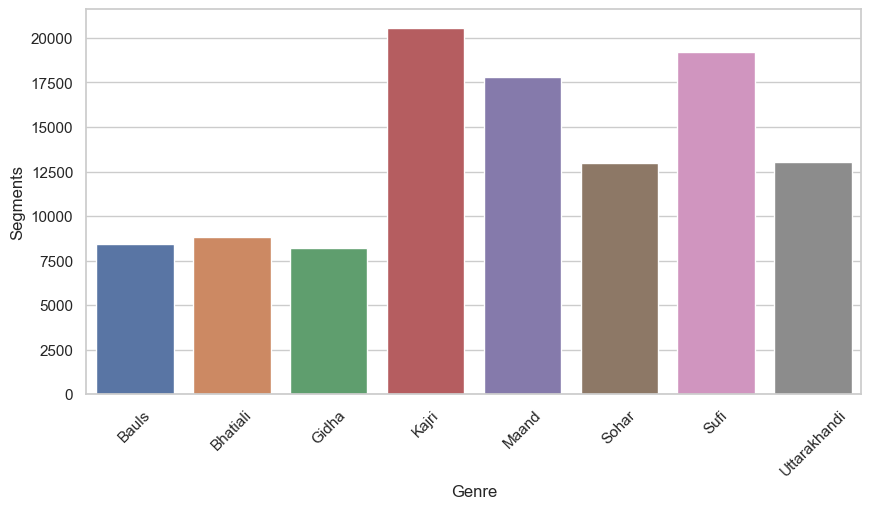

In [4]:
plt.figure(figsize=(10,5))
sns.barplot(data=summary_df,x='Genre',y='Segments',hue='Genre',legend=False)
plt.xticks(rotation=45)
plt.show()

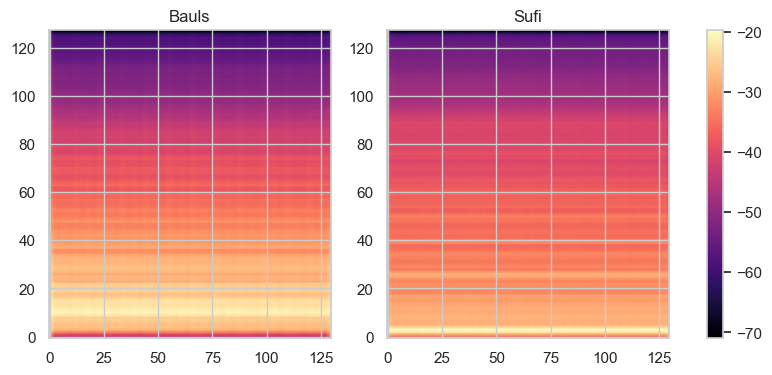

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Convert the path object to a string to check for the genre names
target_files = [f for f in dataset_files if 'Sufi' in str(f) or 'Bauls' in str(f)]
img = None

for ax, file in zip(axes, target_files):
    d = load_dataset(file)
    
    mean_spec = d['mel_spec'].mean(axis=0)
    img = ax.imshow(mean_spec, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(d['genre'][0])
    
fig.colorbar(img, ax=axes)
#plt.tight_layout()
plt.show()

In [6]:
mel_stats=[]
for file in dataset_files:
    d=load_dataset(file)
    m=d['mel_spec']
    mel_stats.append({'Genre':d['genre'][0],'Min':float(m.min()),'Max':float(m.max()),'Mean':float(m.mean()),'Std':float(m.std())})
pd.DataFrame(mel_stats)

,Genre,Min,Max,Mean,Std
0,Bauls,-80.0,0.000004,-43.535736,16.397011
1,Bhatiali,-80.0,0.000004,-43.071693,16.562691
2,Gidha,-80.0,0.000004,-42.184608,16.830545
3,Kajri,-80.0,0.000004,-41.722343,15.878447
4,Maand,-80.0,0.000004,-38.742035,13.795774
5,Sohar,-80.0,0.000004,-43.356377,15.281428
6,Sufi,-80.0,0.000004,-39.360149,13.723644
7,Uttarakhandi,-80.0,0.000004,-37.207550,12.187449


## Observations
Observations for the Jupyter NotebookDataset Distribution and Imbalance: 

The dataset exhibits a significant class imbalance, with Kajri (20,580 segments) and Sufi (19,213 segments) comprising the vast majority of the samples, while Gidha (8,228) and Bauls (8,450) are the least represented. This non-uniform distribution must be accounted for during statistical testing and clustering (e.g., using density-based algorithms or balanced silhouette scores) to prevent bias toward majority classes.  

Dimensional Consistency: All extracted mel-spectrogram segments maintain a strict, uniform matrix shape of (128, 130), ensuring consistent temporal and spectral input dimensions across all 110,689 samples prior to rhythmic feature extraction.  

Acoustic Preprocessing Standardization: The statistical summary shows identical minimum (-80.0) and maximum (0.000004) values across every genre. This confirms that a strict, standardized global normalization and decibel-scaling threshold (an 80 dB dynamic range) was uniformly applied during audio preprocessing.  

Spectral Energy Distribution: The aggregated mean mel-spectrograms reveal that average acoustic energy is heavily concentrated in the lower frequency bands uniformly across all eight folk genres.  